Using device: cuda
Epoch [1/10], Step [200/469], D Loss: 0.3872, G Loss: 2.0251
Epoch [1/10], Step [400/469], D Loss: 0.3060, G Loss: 4.3139


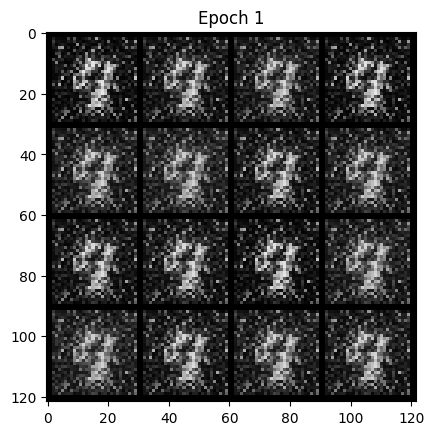

Epoch [2/10], Step [200/469], D Loss: 0.4266, G Loss: 4.6291
Epoch [2/10], Step [400/469], D Loss: 0.2121, G Loss: 3.5132


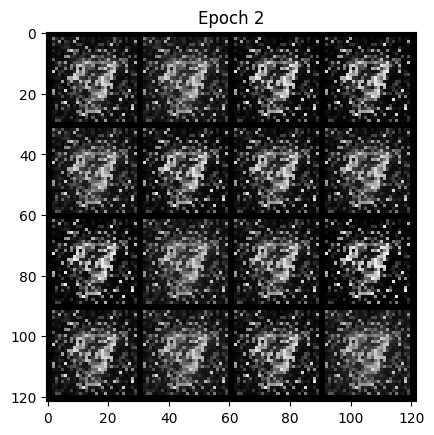

Epoch [3/10], Step [200/469], D Loss: 0.4530, G Loss: 6.8617
Epoch [3/10], Step [400/469], D Loss: 0.6489, G Loss: 6.4030


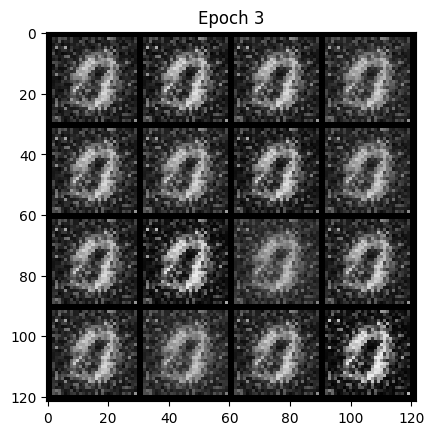

Epoch [4/10], Step [200/469], D Loss: 0.0672, G Loss: 4.5809
Epoch [4/10], Step [400/469], D Loss: 0.1479, G Loss: 4.3195


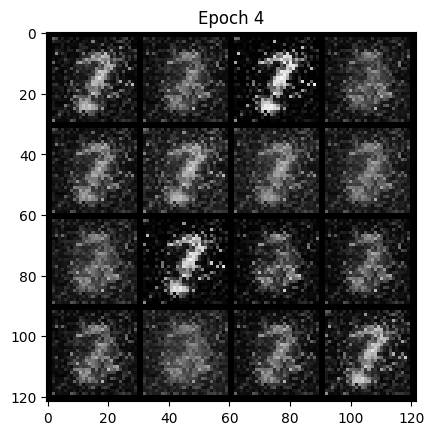

Epoch [5/10], Step [200/469], D Loss: 0.0492, G Loss: 4.4839
Epoch [5/10], Step [400/469], D Loss: 0.4007, G Loss: 2.6893


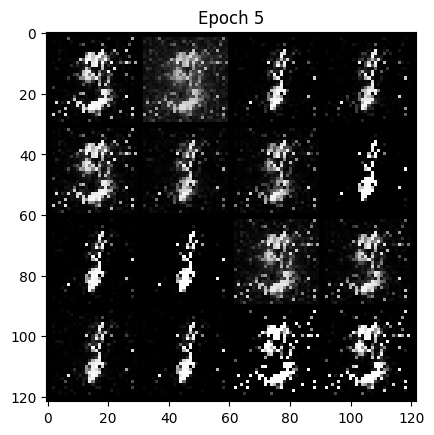

Epoch [6/10], Step [200/469], D Loss: 0.4738, G Loss: 2.4649
Epoch [6/10], Step [400/469], D Loss: 0.2231, G Loss: 4.2394


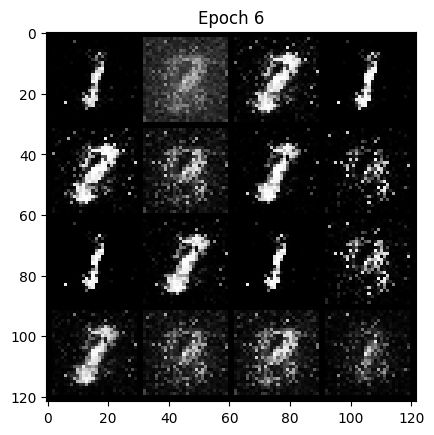

Epoch [7/10], Step [200/469], D Loss: 0.3621, G Loss: 4.3795
Epoch [7/10], Step [400/469], D Loss: 0.2124, G Loss: 3.6265


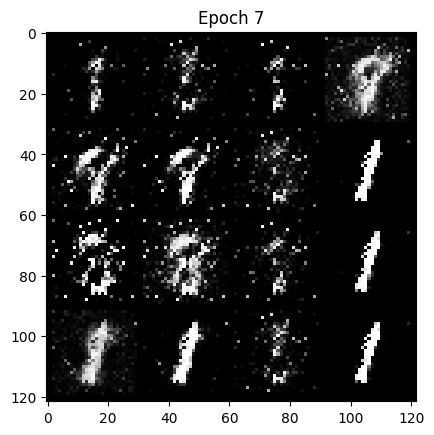

Epoch [8/10], Step [200/469], D Loss: 0.3255, G Loss: 3.8477
Epoch [8/10], Step [400/469], D Loss: 0.7001, G Loss: 2.9244


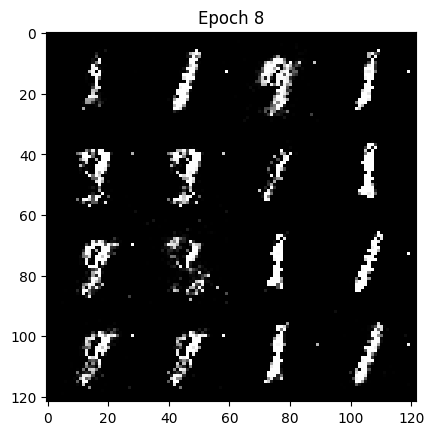

Epoch [9/10], Step [200/469], D Loss: 0.2862, G Loss: 2.7997
Epoch [9/10], Step [400/469], D Loss: 0.3575, G Loss: 2.3156


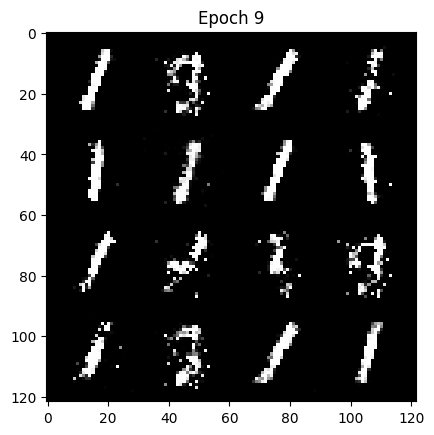

Epoch [10/10], Step [200/469], D Loss: 0.4609, G Loss: 3.7706
Epoch [10/10], Step [400/469], D Loss: 0.3397, G Loss: 2.6497


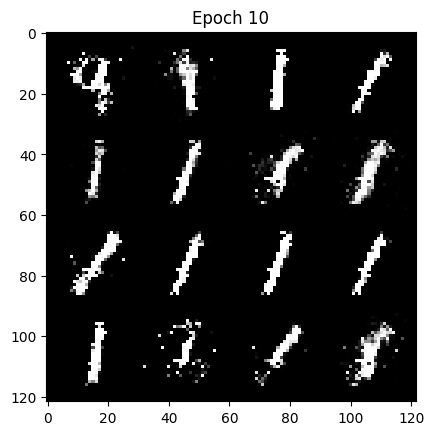

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

torch.use_deterministic_algorithms(False)

# 하이퍼파라미터 설정
latent_dim = 100
batch_size = 128
epochs = 10
lr = 0.0002
beta1 = 0.5

# GPU 사용 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# MNIST 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
data_loader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True)

# Generator 정의
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(out.size(0), 1, 28, 28)

# Discriminator 정의
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input image
        return self.model(x)

# 모델 초기화
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# 손실 함수 및 최적화기 정의
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# 학습 루프
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(data_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # 진짜와 가짜 레이블 생성
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # **1. Discriminator 학습**
        optimizer_D.zero_grad()

        # 진짜 이미지에 대한 손실
        #print(f"Real images shape: {real_images.shape}")  # 이미지 크기 확인
        outputs = discriminator(real_images)
        #print(f"Discriminator output shape: {outputs.shape}")  # 출력 크기 확인
        loss_real = criterion(outputs, real_labels)

        # 가짜 이미지에 대한 손실
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        loss_fake = criterion(outputs, fake_labels)

        # Discriminator의 총 손실 및 역전파
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # **2. Generator 학습**
        optimizer_G.zero_grad()

        # Generator가 생성한 이미지를 판별자에 입력하여 손실 계산
        outputs = discriminator(fake_images)
        loss_G = criterion(outputs, real_labels)

        # 역전파 및 최적화
        loss_G.backward()
        optimizer_G.step()

        # 학습 과정 출력
        if (i + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(data_loader)}], "
                  f"D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

    # 생성된 이미지 샘플 출력
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        fake_images = generator(z)
        fake_images = (fake_images + 1) / 2  # Normalize to [0, 1]
        grid = np.transpose(torchvision.utils.make_grid(fake_images.cpu(), nrow=4, padding=2).numpy(), (1, 2, 0))
        plt.imshow(grid)
        plt.title(f'Epoch {epoch+1}')
        plt.show()


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

Using device: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.60MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:06<00:00, 246kB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.80MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch [1/10], Step [200/469], D Loss: 0.0027, G Loss: 6.7364
Epoch [1/10], Step [400/469], D Loss: 0.5377, G Loss: 1.8662


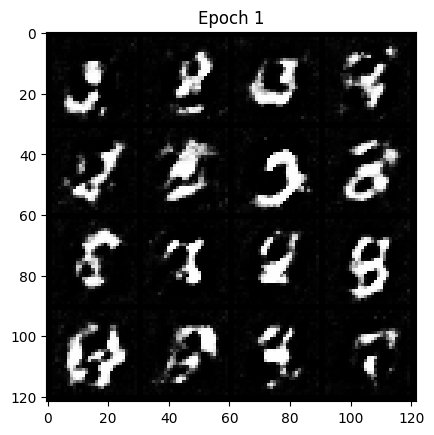

Epoch [2/10], Step [200/469], D Loss: 0.4002, G Loss: 2.2123
Epoch [2/10], Step [400/469], D Loss: 0.3554, G Loss: 2.6055


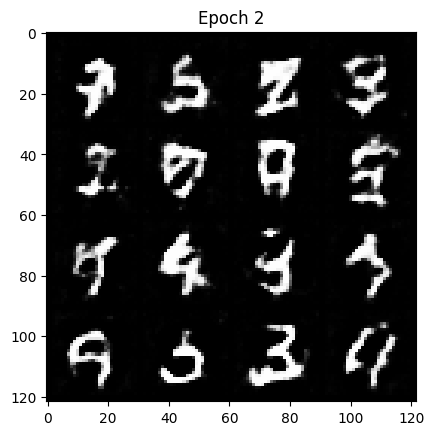

Epoch [3/10], Step [200/469], D Loss: 0.3812, G Loss: 1.4598
Epoch [3/10], Step [400/469], D Loss: 0.3543, G Loss: 2.8242


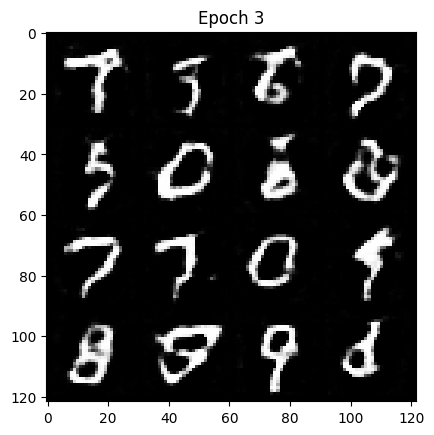

Epoch [4/10], Step [200/469], D Loss: 0.8875, G Loss: 2.5628
Epoch [4/10], Step [400/469], D Loss: 0.4002, G Loss: 3.1681


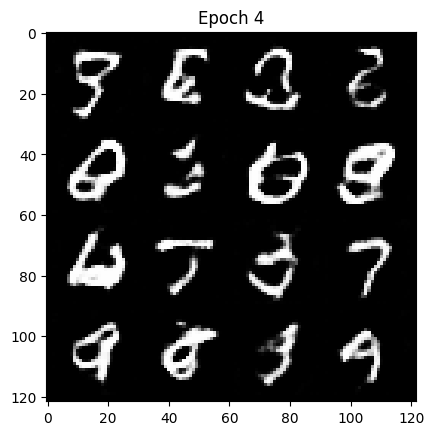

Epoch [5/10], Step [200/469], D Loss: 0.3770, G Loss: 2.3098
Epoch [5/10], Step [400/469], D Loss: 0.3734, G Loss: 1.6756


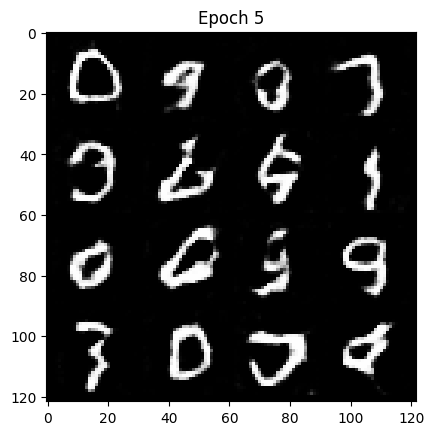

Epoch [6/10], Step [200/469], D Loss: 0.3376, G Loss: 2.2589
Epoch [6/10], Step [400/469], D Loss: 0.8785, G Loss: 0.4849


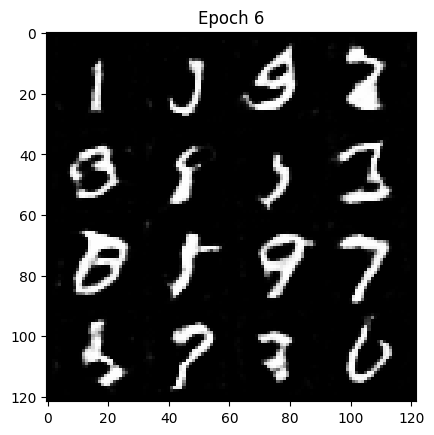

Epoch [7/10], Step [200/469], D Loss: 0.3707, G Loss: 2.2771
Epoch [7/10], Step [400/469], D Loss: 0.3272, G Loss: 2.3257


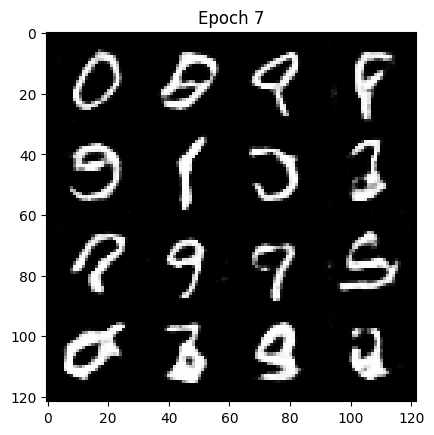

Epoch [8/10], Step [200/469], D Loss: 0.4720, G Loss: 2.1147
Epoch [8/10], Step [400/469], D Loss: 0.4062, G Loss: 2.3308


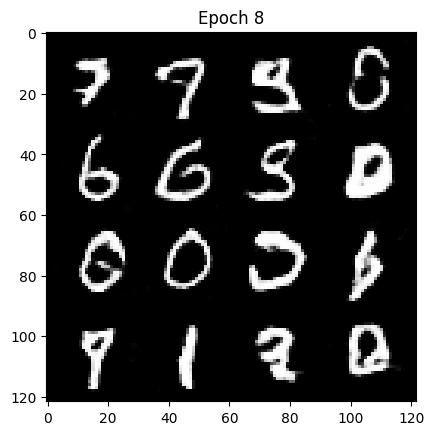

Epoch [9/10], Step [200/469], D Loss: 0.4583, G Loss: 2.3256
Epoch [9/10], Step [400/469], D Loss: 0.4586, G Loss: 1.3968


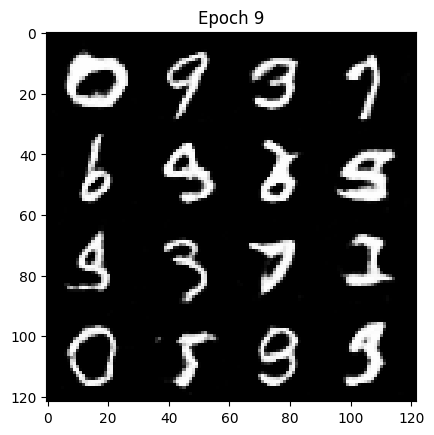

Epoch [10/10], Step [200/469], D Loss: 0.4901, G Loss: 3.1204
Epoch [10/10], Step [400/469], D Loss: 0.3529, G Loss: 2.4473


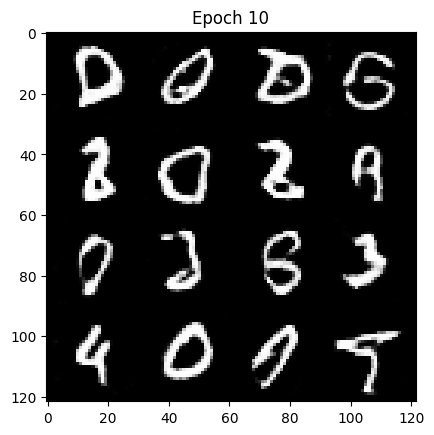

In [2]:
# 랜덤 시드 고정 (재현성을 위해)
torch.manual_seed(0)

# 하이퍼파라미터 설정
latent_dim = 100
batch_size = 128
epochs = 10
lr_G = 0.0001  # Generator 학습률 조정
lr_D = 0.0002  # Discriminator 학습률 조정
beta1 = 0.5

# GPU 사용 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 데이터 전처리 및 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1] 범위로 정규화
])

mnist_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
data_loader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True)

# Generator 정의 (ConvTranspose 사용)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), -1, 1, 1)  # 입력 형태 맞추기
        return self.model(z)

# Discriminator 정의 (Conv 사용)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# 모델 초기화
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# 손실 함수 및 최적화기 정의
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(beta1, 0.999))

# 학습 루프
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(data_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # 진짜와 가짜 레이블 생성
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # **1. Discriminator 학습**
        optimizer_D.zero_grad()

        # 진짜 이미지에 대한 손실
        outputs = discriminator(real_images)
        loss_real = criterion(outputs, real_labels)

        # 가짜 이미지에 대한 손실
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        loss_fake = criterion(outputs, fake_labels)

        # Discriminator의 총 손실 및 역전파
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # **2. Generator 학습**
        optimizer_G.zero_grad()

        # Generator가 생성한 이미지를 판별자에 입력하여 손실 계산
        outputs = discriminator(fake_images)
        loss_G = criterion(outputs, real_labels)

        # 역전파 및 최적화
        loss_G.backward()
        optimizer_G.step()

        # 학습 과정 출력
        if (i + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(data_loader)}], "
                  f"D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

    # 생성된 이미지 샘플 출력
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        fake_images = generator(z)
        fake_images = (fake_images + 1) / 2  # Normalize to [0, 1]
        grid = np.transpose(torchvision.utils.make_grid(fake_images.cpu(), nrow=4, padding=2).numpy(), (1, 2, 0))
        plt.imshow(grid, cmap='gray')
        plt.title(f'Epoch {epoch+1}')
        plt.show()
